In [21]:
# ===== Cell 1 =====

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import yfinance as yf
import os
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from datetime import timedelta
import time
import requests
from datetime import datetime

# Link to your custom model file
from src.models.stock_lstm import StockAttentionLSTM

from torch.utils.data import ConcatDataset, random_split
import csv

%matplotlib inline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# ===== Cell 2 =====

# Refined S&P 500 Ticker List (Top 50 by Market Cap)
# Criteria: Listed > 5 years (before 2021) AND in S&P 500 > 2 years (before 2024)
sp500_tickers = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "BRK.B", "TSLA", "AVGO", "LLY",
    "JPM", "UNH", "V", "MA", "XOM", "PG", "COST", "JNJ", "HD", "MRK",
    "ABBV", "NFLX", "CVX", "BAC", "KO", "AMD", "CRM", "ADBE", "PEP", "TMO",
    "WMT", "ORCL", "DIS", "MCD", "CSCO", "ACN", "INTU", "IBM", "PM", "QCOM",
    "CAT", "TXN", "VZ", "AMGN", "GE", "NOW", "ISRG", "UNP", "LOW", "PFE"
]

print(f"Number of qualifying stocks: {len(sp500_tickers)}")
print("Selection logic: Top 50 by Market Cap with a minimum 5-year history and 2-year index tenure.")

Number of qualifying stocks: 50
Selection logic: Top 50 by Market Cap with a minimum 5-year history and 2-year index tenure.


In [30]:
# ===== Cell 3 =====

data_dir = os.path.join('..', 'Data')
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

for ticker in sp500_tickers:
    file_path = os.path.join(data_dir, f"{ticker}.csv")

    # NEW: Check if file exists AND has content (> 1KB)
    if os.path.exists(file_path) and os.path.getsize(file_path) > 1024:
        continue

    try:
        stooq_ticker = f"{ticker.replace('.', '-')}.US"
        print(f"Downloading {ticker}...", end=" ")

        # Pull 5 years of data for a complete market cycle
        df = web.DataReader(stooq_ticker, 'stooq', start='2020-01-01')

        if not df.empty:
            df = df.sort_index(ascending=True) # Essential for LSTMs
            df.to_csv(file_path)
            print("✅ Success")
        else:
            print("❌ Empty")

        time.sleep(1.2) # Safety buffer

    except Exception as e:
        print(f"💥 Failed: {e}")
        if "429" in str(e):
            print("🛑 Rate limited! Sleeping for 60 seconds...")
            time.sleep(60)

print("\n🚀 Data fully synchronized and verified.")


🚀 Data fully synchronized and verified.


In [31]:
# ===== Cell 4 =====

def add_ma_indicators(data_dir='../Data'):
    print("🛠 Computing 20-day MA percentage distances...")
    for filename in os.listdir(data_dir):
        if filename.endswith(".csv"):
            file_path = os.path.join(data_dir, filename)
            df = pd.read_csv(file_path, index_col=0, parse_dates=True)

            # 1. Compute 20-day Moving Average
            df['MA20'] = df['Close'].rolling(window=20).mean()

            # 2. Percentage Distance: ((Close - MA) / MA) * 100
            # Result: +2.45 for 2.45% above, -3.80 for 3.8% below
            df['Dist_MA20_Pct'] = ((df['Close'] - df['MA20']) / df['MA20']) * 100

            # 3. Clean up: Fill the first 19 NaN days with 0.0
            df['Dist_MA20_Pct'] = df['Dist_MA20_Pct'].fillna(0.0)

            # Save back to CSV
            df.to_csv(file_path)
    print("✅ All stocks updated with 'Dist_MA20_Pct' feature.")

# Run to update your local files
add_ma_indicators()

🛠 Computing 20-day MA percentage distances...
✅ All stocks updated with 'Dist_MA20_Pct' feature.


In [32]:
# ===== Cell 5 =====

class StockDataset(Dataset):
    def __init__(self, ticker_symbol, M=5, t_percent=0.02):
        self.M = M
        self.t = t_percent

        csv_path = os.path.join('..', 'Data', f"{ticker_symbol}.csv")
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)

        # Alignment: Ensure Length % M == 1 for perfect sequential partitioning
        excess_days = (len(df) - 1) % M
        if excess_days > 0:
            df = df.iloc[excess_days:]

        features = df[['Open', 'High', 'Low', 'Close', 'Volume', 'Dist_MA20_Pct']].values
        prices = df['Close'].values

        # Tutorial 08: Standard Scaling (mean=0, var=1)
        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)

        self.X, self.y = [], []

        for i in range(0, len(features_scaled) - M, M):
            self.X.append(features_scaled[i : i + M])

            # 3-Class Labeling Logic (Down, Neutral, Up)
            current_close = prices[i + M - 1]
            next_day_close = prices[i + M]
            change = (next_day_close - current_close) / current_close

            if change >= self.t:
                label = 2 # UP
            elif change <= -self.t:
                label = 0 # DOWN
            else:
                label = 1 # NEUTRAL
            self.y.append(label)

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        # CrossEntropy expects Long tensors for labels (Tutorial 05)
        self.y = torch.tensor(np.array(self.y), dtype=torch.long)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [39]:
# ===== Cell 6 =====

all_datasets = []
for ticker in sp500_tickers:
    try:
        ds = StockDataset(ticker, M=5, t_percent=0.02)
        if len(ds) > 0: all_datasets.append(ds)
    except Exception: continue

full_dataset = ConcatDataset(all_datasets)
train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# Calculate Weights for 3 classes to handle imbalance (Tutorial 08)
all_labels = torch.cat([ds.y for ds in all_datasets])
class_counts = torch.bincount(all_labels)
# Inverse frequency weighting
weights = 1.0 / class_counts.float()
weights = weights / weights.sum() * 3.0 # Normalize
class_weights = weights.to(device)

print(f"Class Weights (Down/Neutral/Up): {class_weights.tolist()}")

Class Weights (Down/Neutral/Up): [1.4979180097579956, 0.19940024614334106, 1.3026819229125977]


In [40]:
# ===== Cell 7 =====

# --- 1. Global Hyperparameters & Metadata ---
M = 5
t_val = 0.02
epochs = 100
input_dim = 6      # UPDATED: 5 original + 1 (Dist_MA20_Pct)
hidden_dim = 128
num_layers = 2
output_dim = 3
lr = 0.0001
weight_decay = 1e-4
patience = 25
architecture_name = "StockAttentionLSTM"
notes = "Added Dist_MA20_Pct feature, Early Stopping, and StepLR."

# --- 2. Define Initialization Function ---
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None: nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.LSTM):
        for name, param in m.named_parameters():
            if 'weight' in name: nn.init.orthogonal_(param.data)

# --- 3. Model & Logbook Setup ---
model = StockAttentionLSTM(input_dim, hidden_dim, num_layers).to(device)
model.apply(weights_init)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

log_file = 'experiment_logbook.csv'
if not os.path.exists(log_file):
    with open(log_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Run_ID', 'Timestamp', 'Arch', 'M', 't_val', 'LR', 'WD', 'Layers', 'Hidden', 'Best_Val_Acc', 'Notes'])

print(f"✅ Run Initialized: {architecture_name} with input_dim={input_dim} on {device}.")

✅ Run Initialized: StockAttentionLSTM with input_dim=6 on cpu.


In [41]:
# ===== Cell 8 =====

# --- 1. Tracking and Initialization ---
early_stop_counter = 0
best_val_acc = 0.0
current_run_id = datetime.now().strftime("%Y%m%d_%H%M%S") # Chronological ID

history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'test_acc': [], 'lr': []}

print(f"🚀 Starting Run ID: {current_run_id} | Architecture: {architecture_name}")

# --- 2. Master Loop ---
for epoch in range(epochs):
    model.train()
    train_correct, train_total, running_loss = 0, 0, 0.0
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        train_correct += (torch.argmax(outputs, dim=1) == batch_y).sum().item()
        train_total += batch_y.size(0)

    # --- 3. Evaluation (Val AND Test) ---
    model.eval()
    val_correct, val_total = 0, 0
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for bX, bY in val_loader:
            bX, bY = bX.to(device), bY.to(device)
            val_out = model(bX)
            val_correct += (torch.argmax(val_out, dim=1) == bY).sum().item()
            val_total += bY.size(0)

        for bX, bY in test_loader: # Added to support plotting
            bX, bY = bX.to(device), bY.to(device)
            test_out = model(bX)
            test_correct += (torch.argmax(test_out, dim=1) == bY).sum().item()
            test_total += bY.size(0)

    # Record History
    history['train_loss'].append(running_loss / len(train_loader))
    history['train_acc'].append(100 * train_correct / train_total)
    history['val_acc'].append(100 * val_correct / val_total)
    history['test_acc'].append(100 * test_correct / test_total)

    # --- 4. Automatic Logging & Checkpointing ---
    if history['val_acc'][-1] > best_val_acc:
        best_val_acc = history['val_acc'][-1]
        torch.save(model.state_dict(), f'best_model_{current_run_id}.pth')
        early_stop_counter = 0

        log_data = {
            'Run_ID': current_run_id,
            'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Epoch': epoch + 1,
            'M': M,
            't_val': t_val,
            'Best_Val_Acc': f"{best_val_acc:.2f}%",
            'LR': current_lr,
            'Architecture': architecture_name,
            'Notes': notes
        }

        with open(log_file, 'a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=log_data.keys())
            writer.writerow(log_data)

        print(f"Epoch {epoch+1:03d} | 🌟 New Best! Val Acc: {best_val_acc:.2f}% (Logged)")
    else:
        early_stop_counter += 1

    scheduler.step()
    if early_stop_counter >= patience:
        print(f"🛑 Early Stopping at epoch {epoch+1}")
        break

print(f"\n✅ Training Finished. Best Val Accuracy: {best_val_acc:.2f}%")

🚀 Starting Run ID: 20260115_200448 | Architecture: StockAttentionLSTM
Epoch 001 | 🌟 New Best! Val Acc: 60.21% (Logged)
Epoch 005 | 🌟 New Best! Val Acc: 63.34% (Logged)
Epoch 012 | 🌟 New Best! Val Acc: 65.49% (Logged)
Epoch 016 | 🌟 New Best! Val Acc: 66.33% (Logged)
Epoch 019 | 🌟 New Best! Val Acc: 66.77% (Logged)
🛑 Early Stopping at epoch 44

✅ Training Finished. Best Val Accuracy: 66.77%


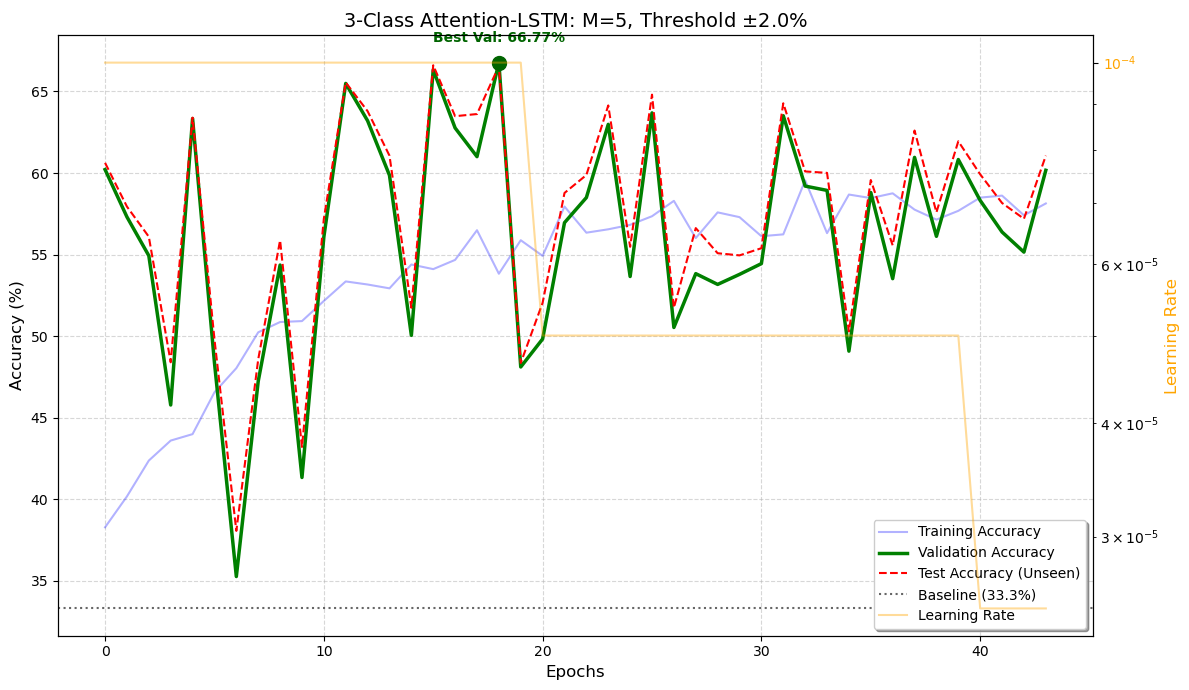

In [42]:
# ===== Cell 9 =====

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Primary Axis: Accuracies ---
ax1.plot(history['train_acc'], label='Training Accuracy', color='blue', alpha=0.3)
ax1.plot(history['val_acc'], label='Validation Accuracy', color='green', linewidth=2.5)
ax1.plot(history['test_acc'], label='Test Accuracy (Unseen)', color='red', linestyle='--')

ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title(f'3-Class Attention-LSTM: M={M}, Threshold $\pm${t_val*100}%', fontsize=14)

# Random baseline for 3 classes (Tutorial 05)
ax1.axhline(33.3, color='black', linestyle=':', label='Baseline (33.3%)', alpha=0.6)

# --- Secondary Axis: Learning Rate (Tutorial 08 Practice) ---
ax2 = ax1.twinx()
ax2.plot(history['lr'], color='orange', label='Learning Rate', linestyle='-', alpha=0.4)
ax2.set_ylabel('Learning Rate', color='orange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_yscale('log') # LR changes are usually exponential/step-wise

# Combine Legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', frameon=True, shadow=True)

ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Highlight Best Generalization Point
best_epoch = np.argmax(history['val_acc'])
ax1.scatter(best_epoch, history['val_acc'][best_epoch], color='darkgreen', s=100, zorder=5)
ax1.annotate(f"Best Val: {history['val_acc'][best_epoch]:.2f}%",
             (best_epoch, history['val_acc'][best_epoch]),
             textcoords="offset points", xytext=(0,15), ha='center', weight='bold', color='darkgreen')

plt.tight_layout()
plt.show()